## 1. Configuración del modelo (ÚNICA celda a editar entre modelos)

In [1]:
# CONFIGURACIÓN DEL MODELO — editar esto para cada modelo
# ============================
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
MODEL_SHORT_NAME = "llama3_1_8b_instruct"

MODEL_TYPE = "causal_lm"              # arquitectura Llama estándar, sin visión
SUPPORTS_ENABLE_THINKING = False      # no tiene modo thinking

# Configuración general
# ============================
SEED = 42
MAX_NEW_TOKENS = 10        # la respuesta esperada es solo la etiqueta, no necesitamos generar mucho texto
TEMPERATURE = 0.0          # determinismo: queremos la respuesta más probable, no variabilidad creativa
DO_SAMPLE = False          # con temperature=0 y do_sample=False, la generación es reproducible

RUTA_VAL = "/content/val_final.csv"
RUTA_TEST = "/content/test_final.csv"

CHECKPOINT_CADA = 200      # cada cuántos ejemplos se guarda un checkpoint parcial durante el loop


## 2. Instalación de dependencias


In [2]:
#!pip install -q "transformers==5.10.4" accelerate "kernels==0.10.3"

import transformers
print("Versión de transformers instalada:", transformers.__version__)

import torch
print("Versión de torch instalada:", torch.__version__)
print("Versión de CUDA (torch):", torch.version.cuda)


Versión de transformers instalada: 5.13.1
Versión de torch instalada: 2.11.0+cu128
Versión de CUDA (torch): 12.8


## 3. Verificación de GPU

In [3]:
print("GPU disponible:", torch.cuda.is_available())
print("Nombre GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")


GPU disponible: True
Nombre GPU: NVIDIA L4


## 4. Login a Hugging Face

In [4]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

print("Login exitoso")


Login exitoso


## 5. Cargar el dataset de validación

In [5]:
import pandas as pd

df_val = pd.read_csv(RUTA_VAL)

print("Validation cargado:", df_val.shape)
print(df_val["label_name"].value_counts())
df_val.head()


Validation cargado: (1454, 4)
label_name
negative    663
positive    473
neutral     318
Name: count, dtype: int64


,text,text_clean,label,label_name
0,"Daniella, un sanguchito de pavo en Astoria y l...","Daniella, un sanguchito de pavo en Astoria y l...",2,positive
1,Cocoros 🙂. Cuando vivía en talara era mi punto.,Cocoros 🙂. Cuando vivía en talara era mi punto.,1,neutral
2,Jaja se elegierón los corruptos al asu aliado ...,Jaja se elegierón los corruptos al asu aliado ...,0,negative
3,"Fatima, la caminada en tacos fue todo! Ya me...","Fatima, la caminada en tacos fue todo! Ya me v...",1,neutral
4,"El injerto resollaba, emitía grititos destempl...","El injerto resollaba, emitía grititos destempl...",0,negative


## 6. Definición de los 5 prompts (Tabla 6)

In [6]:
PROMPTS = {
    1: {
        "system": None,
        "user": "Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: {text}"
    },
    2: {
        "system": None,
        "user": "Para el texto proporcionado, analiza su sentimiento y clasifícalo únicamente en una de las siguientes clases: negativo, neutral, positivo. Texto: {text}"
    },
    3: {
        "system": None,
        "user": "Clasifica el sentimiento del texto en español peruano informal en solo una de las siguientes categorías: negativo, neutral, positivo. Texto: {text}"
    },
    4: {
        "system": "Eres un clasificador de sentimientos de comentarios en español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo.",
        "user": "Clasifica el siguiente comentario. Comentario: {text}"
    },
    5: {
        "system": "Eres un experto en clasificar el sentimiento de textos que pueden contener jergas o expresiones coloquiales del español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo. No brindes texto adicional.",
        "user": "Clasifica el siguiente texto. Texto: {text}"
    },
}

def construir_mensajes(prompt_id: int, texto: str):
    """Devuelve la lista de mensajes (formato chat) para un prompt_id y un texto dado."""
    config = PROMPTS[prompt_id]
    mensajes = []
    if config["system"] is not None:
        mensajes.append({"role": "system", "content": config["system"]})
    mensajes.append({"role": "user", "content": config["user"].format(text=texto)})
    return mensajes


texto_ejemplo = df_val.iloc[0]["text_clean"]
for pid in PROMPTS:
    print(f"--- Prompt {pid} ---")
    print(construir_mensajes(pid, texto_ejemplo))
    print()


--- Prompt 1 ---
[{'role': 'user', 'content': 'Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 2 ---
[{'role': 'user', 'content': 'Para el texto proporcionado, analiza su sentimiento y clasifícalo únicamente en una de las siguientes clases: negativo, neutral, positivo. Texto: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 3 ---
[{'role': 'user', 'content': 'Clasifica el sentimiento del texto en español peruano informal en solo una de las siguientes categorías: negativo, neutral, positivo. Texto: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 4 ---
[{'role': 'system', 'content': 'Eres un clasificador de sentimientos de comentarios en español peruano. Responde únicamente con una de las s

## 7. Carga del modelo

Esta celda se adapta automáticamente según `MODEL_TYPE` definido en la Sección 1.

In [7]:
import time
import torch

print(f"Cargando modelo: {MODEL_ID}  (tipo: {MODEL_TYPE})")
t0 = time.time()

if MODEL_TYPE == "multimodal":
    from transformers import AutoProcessor, AutoModelForMultimodalLM

    processor = AutoProcessor.from_pretrained(MODEL_ID, token=hf_token)
    model = AutoModelForMultimodalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=hf_token,
    )
    tokenizer = processor.tokenizer

elif MODEL_TYPE == "causal_lm":
    from transformers import AutoTokenizer, AutoModelForCausalLM

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=hf_token,
    )
    processor = None  # no aplica para modelos de solo texto

else:
    raise ValueError(f"MODEL_TYPE debe ser 'multimodal' o 'causal_lm', recibido: {MODEL_TYPE}")

tiempo_carga = time.time() - t0

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.eval()

print(f"Modelo cargado en {tiempo_carga:.1f} segundos")
print(f"Memoria GPU reservada tras cargar: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"Memoria GPU asignada tras cargar: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


Cargando modelo: meta-llama/Llama-3.1-8B-Instruct  (tipo: causal_lm)


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Modelo cargado en 63.6 segundos
Memoria GPU reservada tras cargar: 16.06 GB
Memoria GPU asignada tras cargar: 16.06 GB


In [8]:
import random
import numpy as np

def fijar_semilla(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

fijar_semilla(SEED)


## 8. Función de generación (unificada para ambos tipos de modelo)

Esta función abstrae la diferencia entre `processor.apply_chat_template` (multimodal) y `tokenizer.apply_chat_template` (causal_lm estándar), y entre modelos que soportan `enable_thinking` y los que no.

In [9]:
def generar_respuesta(mensajes):
    kwargs_template = dict(
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    if SUPPORTS_ENABLE_THINKING:
        kwargs_template["enable_thinking"] = False

    if MODEL_TYPE == "multimodal":
        inputs = processor.apply_chat_template(mensajes, **kwargs_template).to(model.device)
    else:
        inputs = tokenizer.apply_chat_template(mensajes, **kwargs_template).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            pad_token_id=tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id,
        )

    respuesta = tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    return respuesta


# Prueba rápida con un solo ejemplo antes de correr todo el dataset
mensajes_prueba = construir_mensajes(1, texto_ejemplo)
respuesta_prueba = generar_respuesta(mensajes_prueba)
print("--- Respuesta generada (prueba) ---")
print(repr(respuesta_prueba))


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


--- Respuesta generada (prueba) ---
'Positivo'


**Antes de seguir:** revisa la respuesta de la celda de arriba.
- Si aparece un bloque de razonamiento largo (tipo `<think>...</think>`) en vez de una respuesta directa, y `SUPPORTS_ENABLE_THINKING = True` no lo evitó, es posible que este modelo use un nombre distinto de parámetro o un mecanismo distinto para desactivar el pensamiento (revisa su ficha en Hugging Face).
- Si el modelo simplemente no tiene modo thinking, la respuesta debería salir directa sin que hayamos tenido que hacer nada especial.

Si la respuesta se ve razonable (una palabra o frase corta reconocible como clase), sigue a la Sección 9.

## 9. Función de parseo de la respuesta a una de las 3 clases

In [10]:
import re
import unicodedata

def normalizar_texto(texto: str) -> str:
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def parsear_respuesta(respuesta: str) -> str:
    texto = normalizar_texto(respuesta)

    tiene_negativo = bool(re.search(r"\bnegativ", texto))
    tiene_neutral = bool(re.search(r"\bneutral", texto))
    tiene_positivo = bool(re.search(r"\bpositiv", texto))

    encontrados = [
        etiqueta for etiqueta, encontrado in
        [("negative", tiene_negativo), ("neutral", tiene_neutral), ("positive", tiene_positivo)]
        if encontrado
    ]

    if len(encontrados) == 1:
        return encontrados[0]
    else:
        return "invalido"


casos_prueba = ["positivo\n", "Negativo.", "La respuesta es: NEUTRAL", "no estoy seguro", "positivo o neutral"]
for caso in casos_prueba:
    print(f"{caso!r:40} -> {parsear_respuesta(caso)}")


'positivo\n'                             -> positive
'Negativo.'                              -> negative
'La respuesta es: NEUTRAL'               -> neutral
'no estoy seguro'                        -> invalido
'positivo o neutral'                     -> invalido


## 10. Loop de evaluación sobre validation (5 prompts), con logging completo

In [11]:
!pip install -q tqdm


In [12]:
import time
import torch
import pandas as pd
from tqdm.auto import tqdm

def evaluar_modelo_en_prompt(df, prompt_id, checkpoint_cada=CHECKPOINT_CADA, nombre_archivo=None):
    fijar_semilla(SEED)

    resultados = []
    torch.cuda.reset_peak_memory_stats()
    t_inicio = time.time()

    for idx, fila in tqdm(df.iterrows(), total=len(df), desc=f"Prompt {prompt_id}"):
        texto = fila["text_clean"]
        mensajes = construir_mensajes(prompt_id, texto)
        respuesta_cruda = generar_respuesta(mensajes)
        prediccion = parsear_respuesta(respuesta_cruda)

        resultados.append({
            "idx_original": idx,
            "text_clean": texto,
            "label_name": fila["label_name"],
            "prompt_id": prompt_id,
            "respuesta_cruda": respuesta_cruda,
            "prediccion": prediccion,
        })

        if nombre_archivo and (len(resultados) % checkpoint_cada == 0):
            pd.DataFrame(resultados).to_csv(nombre_archivo, index=False)

    tiempo_total = time.time() - t_inicio
    memoria_pico_gb = torch.cuda.max_memory_allocated() / 1e9

    df_resultados = pd.DataFrame(resultados)
    if nombre_archivo:
        df_resultados.to_csv(nombre_archivo, index=False)

    metadata = {
        "modelo": MODEL_ID,
        "prompt_id": prompt_id,
        "seed": SEED,
        "max_new_tokens": MAX_NEW_TOKENS,
        "temperature": TEMPERATURE,
        "do_sample": DO_SAMPLE,
        "n_ejemplos": len(df),
        "tiempo_total_seg": round(tiempo_total, 1),
        "tiempo_promedio_por_ejemplo_seg": round(tiempo_total / len(df), 3),
        "memoria_pico_gb": round(memoria_pico_gb, 2),
    }

    return df_resultados, metadata


In [13]:
resultados_por_prompt = {}
log_experimentos = []

for prompt_id in PROMPTS:
    nombre_archivo = f"val_{MODEL_SHORT_NAME}_prompt{prompt_id}.csv"
    df_res, metadata = evaluar_modelo_en_prompt(
        df_val, prompt_id, checkpoint_cada=CHECKPOINT_CADA, nombre_archivo=nombre_archivo
    )
    resultados_por_prompt[prompt_id] = df_res
    log_experimentos.append(metadata)
    print(f"Prompt {prompt_id} terminado -> {metadata}")

df_log = pd.DataFrame(log_experimentos)
df_log.to_csv(f"log_experimentos_{MODEL_SHORT_NAME}_validation.csv", index=False)
df_log


Prompt 1:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 1 terminado -> {'modelo': 'meta-llama/Llama-3.1-8B-Instruct', 'prompt_id': 1, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 377.1, 'tiempo_promedio_por_ejemplo_seg': 0.259, 'memoria_pico_gb': 16.6}


Prompt 2:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 2 terminado -> {'modelo': 'meta-llama/Llama-3.1-8B-Instruct', 'prompt_id': 2, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 964.3, 'tiempo_promedio_por_ejemplo_seg': 0.663, 'memoria_pico_gb': 16.61}


Prompt 3:   0%|          | 0/1454 [00:00<?, ?it/s]

...

Prompt 4:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 4 terminado -> {'modelo': 'meta-llama/Llama-3.1-8B-Instruct', 'prompt_id': 4, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 632.9, 'tiempo_promedio_por_ejemplo_seg': 0.435, 'memoria_pico_gb': 16.61}


Prompt 5:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 5 terminado -> {'modelo': 'meta-llama/Llama-3.1-8B-Instruct', 'prompt_id': 5, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 380.4, 'tiempo_promedio_por_ejemplo_seg': 0.262, 'memoria_pico_gb': 16.62}


,modelo,prompt_id,seed,max_new_tokens,temperature,do_sample,n_ejemplos,tiempo_total_seg,tiempo_promedio_por_ejemplo_seg,memoria_pico_gb
0,meta-llama/Llama-3.1-8B-Instruct,1,42,10,0.0,False,1454,377.1,0.259,16.60
1,meta-llama/Llama-3.1-8B-Instruct,2,42,10,0.0,False,1454,964.3,0.663,16.61
2,meta-llama/Llama-3.1-8B-Instruct,3,42,10,0.0,False,1454,964.1,0.663,16.61
3,meta-llama/Llama-3.1-8B-Instruct,4,42,10,0.0,False,1454,632.9,0.435,16.61
4,meta-llama/Llama-3.1-8B-Instruct,5,42,10,0.0,False,1454,380.4,0.262,16.62


## 11. Métricas por prompt y selección del mejor prompt para este modelo

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import pandas as pd

CLASES = ["negative", "neutral", "positive"]

def calcular_metricas(df_resultados, prompt_id):
    y_true = df_resultados["label_name"]
    y_pred = df_resultados["prediccion"]

    n_invalidos = (y_pred == "invalido").sum()
    pct_invalidos = round(100 * n_invalidos / len(df_resultados), 2)

    accuracy = accuracy_score(y_true, y_pred)  # robusto a etiquetas "invalido" fuera de CLASES

    reporte = classification_report(
        y_true, y_pred, labels=CLASES, output_dict=True, zero_division=0
    )
    macro_f1 = f1_score(y_true, y_pred, labels=CLASES, average="macro", zero_division=0)
    matriz = confusion_matrix(y_true, y_pred, labels=CLASES)

    resumen = {
        "prompt_id": prompt_id,
        "accuracy": round(accuracy, 4),
        "macro_f1": round(macro_f1, 4),
        "precision_negative": round(reporte["negative"]["precision"], 4),
        "recall_negative": round(reporte["negative"]["recall"], 4),
        "f1_negative": round(reporte["negative"]["f1-score"], 4),
        "precision_neutral": round(reporte["neutral"]["precision"], 4),
        "recall_neutral": round(reporte["neutral"]["recall"], 4),
        "f1_neutral": round(reporte["neutral"]["f1-score"], 4),
        "precision_positive": round(reporte["positive"]["precision"], 4),
        "recall_positive": round(reporte["positive"]["recall"], 4),
        "f1_positive": round(reporte["positive"]["f1-score"], 4),
        "pct_invalidos": pct_invalidos,
    }
    return resumen, matriz


resumenes = []
matrices = {}

for prompt_id in PROMPTS:
    df_res = resultados_por_prompt[prompt_id]
    resumen, matriz = calcular_metricas(df_res, prompt_id)
    resumenes.append(resumen)
    matrices[prompt_id] = matriz

df_comparacion_prompts = pd.DataFrame(resumenes)
df_comparacion_prompts.to_csv(f"comparacion_prompts_{MODEL_SHORT_NAME}_validation.csv", index=False)

mejor_prompt = df_comparacion_prompts.loc[df_comparacion_prompts["macro_f1"].idxmax(), "prompt_id"]
print(f"Mejor prompt para {MODEL_ID} (según macro-F1 en validation): Prompt {mejor_prompt}")
df_comparacion_prompts.sort_values("macro_f1", ascending=False)

Mejor prompt para meta-llama/Llama-3.1-8B-Instruct (según macro-F1 en validation): Prompt 1


,prompt_id,accuracy,macro_f1,precision_negative,recall_negative,f1_negative,precision_neutral,recall_neutral,f1_neutral,precision_positive,recall_positive,f1_positive,pct_invalidos
0,1,0.6320,0.5215,0.7844,0.6968,0.7380,0.7895,0.0943,0.1685,0.5176,0.9027,0.6579,0.14
3,4,0.6142,0.5210,0.7955,0.6456,0.7127,0.7391,0.1069,0.1868,0.5218,0.9112,0.6636,3.03
4,5,0.5997,0.4869,0.8019,0.6290,0.7050,0.7586,0.0692,0.1268,0.4790,0.9154,0.6289,0.07
1,2,0.1121,0.1638,0.7436,0.0875,0.1565,1.0000,0.0063,0.0125,0.6205,0.2178,0.3224,83.08
2,3,0.0028,0.0044,0.6000,0.0045,0.0090,0.0000,0.0000,0.0000,0.5000,0.0021,0.0042,99.52


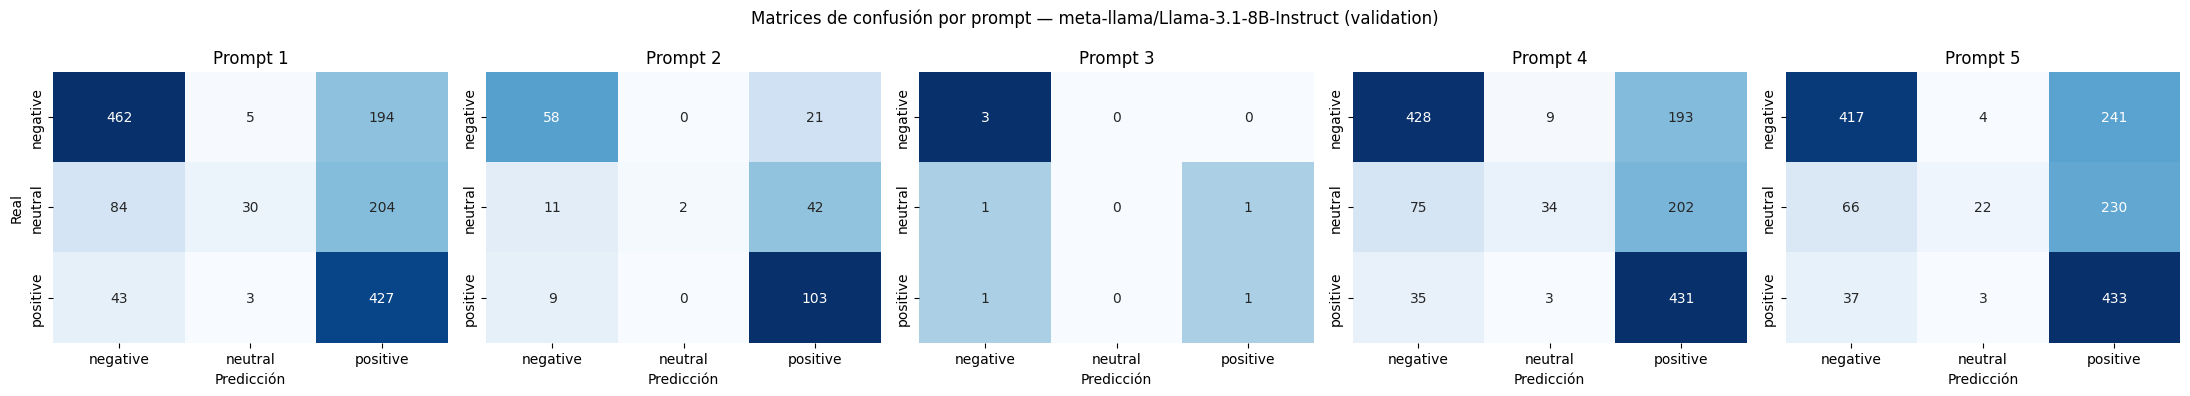

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, prompt_id in enumerate(PROMPTS):
    sns.heatmap(
        matrices[prompt_id], annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASES, yticklabels=CLASES, ax=axes[i], cbar=False
    )
    axes[i].set_title(f"Prompt {prompt_id}")
    axes[i].set_xlabel("Predicción")
    if i == 0:
        axes[i].set_ylabel("Real")

plt.suptitle(f"Matrices de confusión por prompt — {MODEL_ID} (validation)")
plt.tight_layout()
plt.savefig(f"matrices_confusion_{MODEL_SHORT_NAME}_validation.png", dpi=150)
plt.show()


In [17]:
# Revisar el colapso del Prompt 3 (el más extremo)
df_prompt3 = resultados_por_prompt[3]
print(df_prompt3["prediccion"].value_counts())
print()
print("Ejemplos de respuesta_cruda (Prompt 3):")
print(df_prompt3[df_prompt3["prediccion"] == "invalido"]["respuesta_cruda"].head(10).tolist())

prediccion
invalido    1447
negative       5
positive       2
Name: count, dtype: int64

Ejemplos de respuesta_cruda (Prompt 3):
['La clasificación del sentimiento del texto es:', 'La clasificación del sentimiento del texto es:', 'La categoría del sentimiento de este texto es', 'La clasificación del sentimiento del texto es:', 'La categoría del sentimiento de este texto es', 'La clasificación del sentimiento del texto es:', 'La clasificación del sentimiento del texto es:', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento del texto es:', 'La clasificación del sentimiento de este texto es']


In [18]:
# Y el Prompt 2, también muy alto (83%)
df_prompt2 = resultados_por_prompt[2]
print(df_prompt2["prediccion"].value_counts())
print()
print("Ejemplos de respuesta_cruda (Prompt 2):")
print(df_prompt2[df_prompt2["prediccion"] == "invalido"]["respuesta_cruda"].head(10).tolist())

prediccion
invalido    1208
positive     166
negative      78
neutral        2
Name: count, dtype: int64

Ejemplos de respuesta_cruda (Prompt 2):
['La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es', 'La clasificación del sentimiento de este texto es']
